# 02 — Propensity Score Matching (PSM)

## Overview

In notebook 01, we established that confounding by **Stage, Age, and Cancer Type** biases naive estimates of chemotherapy's effect on survival. Now we implement **Propensity Score Matching (PSM)** — a non-parametric approach to control for these confounders.

The propensity score, $e(X) = P(\text{Chemo}=1 | X)$, is a **balancing score**: conditioning on $e(X)$ is sufficient to remove confounding by all measured covariates $X$. This allows us to compare treated and untreated patients who had the *same predicted probability* of receiving chemotherapy — i.e., patients who were observationally similar.

## Biological Motivation

This approach directly addresses **indication bias**:

> A Stage IV lung cancer patient who received chemo should be compared to a Stage IV lung cancer patient of similar age who did *not* receive chemo — not to an average untreated patient who might be Stage I.

PSM creates a pseudo-randomized comparison by ensuring treated and control patients are **exchangeable** on measured confounders, mimicking what an RCT would achieve by design.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, glob, urllib.request, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

DATA_DIR    = os.path.abspath('../data')
RAW_DIR     = os.path.join(DATA_DIR, 'raw')
PROC_DIR    = os.path.join(DATA_DIR, 'processed')
FIGURES_DIR = os.path.abspath('../results/figures')
TCGA_URL    = 'https://cbioportal-datahub.s3.amazonaws.com/tcga_pan_can_atlas_2018.tar.gz'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded.')


Libraries loaded.


## 1. Load and Prepare TCGA Data

In [2]:
# Data is loaded from data/processed/analysis_dataset.parquet
# Built by build_real_dataset.py from real TCGA Pan-Cancer Atlas 2018 clinical files.
# Run fetch_lfs_clinical.py + build_real_dataset.py to create it,
# or generate_synthetic_data.py for offline use.
def download_tcga_if_needed():
    os.makedirs(RAW_DIR, exist_ok=True)
    tarball = os.path.join(RAW_DIR, 'tcga_pan_can_atlas_2018.tar.gz')
    extract_dir = os.path.join(RAW_DIR, 'tcga_pan_can_atlas_2018')
    if not os.path.exists(tarball):
        print(f'Downloading TCGA Pan-Cancer Atlas 2018 (~2 GB) ...')
        urllib.request.urlretrieve(TCGA_URL, tarball)
        print('Download complete.')
    if not os.path.exists(extract_dir) or len(os.listdir(extract_dir)) < 5:
        print('Extracting ...')
        with tarfile.open(tarball, 'r:gz') as t:
            t.extractall(RAW_DIR)
        print('Extraction complete.')
    return extract_dir


def load_tcga_clinical(data_dir):
    files = glob.glob(os.path.join(data_dir, '*', 'data_clinical_patient.txt'))
    if not files:
        direct = os.path.join(data_dir, 'data_clinical_patient.txt')
        files = [direct] if os.path.exists(direct) else []
    if not files:
        raise FileNotFoundError('data_clinical_patient.txt not found. '
                                'Check data/README.md for download instructions.')
    dfs = []
    for f in files:
        cancer_abbr = os.path.basename(os.path.dirname(f)).split('_tcga')[0].upper()
        df = pd.read_csv(f, sep='\t', comment='#', low_memory=False)
        df.columns = df.columns.str.upper()
        df['CANCER_TYPE_ABBR'] = cancer_abbr
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def build_analysis_dataset(raw_df):
    df = raw_df.copy()

    # --- Survival outcome ---
    df['OS_MONTHS'] = pd.to_numeric(df.get('OS_MONTHS', pd.Series(dtype=float)),
                                     errors='coerce')
    df['OS_EVENT'] = df.get('OS_STATUS', pd.Series(dtype=str)).apply(
        lambda x: 1 if str(x).upper() in ['1:DECEASED', 'DECEASED', '1'] else
                  0 if str(x).upper() in ['0:LIVING', 'LIVING', '0'] else np.nan
    )

    # --- Age ---
    age_col = next((c for c in ['AGE', 'DIAGNOSIS_AGE'] if c in df.columns), None)
    df['AGE'] = pd.to_numeric(df[age_col], errors='coerce') if age_col else np.nan

    # --- Stage ---
    stage_col = next((c for c in ['AJCC_PATHOLOGIC_TUMOR_STAGE', 'TUMOR_STAGE',
                                   'CLINICAL_STAGE'] if c in df.columns), None)
    def parse_stage(s):
        s = str(s).upper()
        if 'IV' in s:  return 4
        if 'III' in s: return 3
        if 'II' in s:  return 2
        if 'I' in s:   return 1
        return np.nan
    df['STAGE'] = df[stage_col].apply(parse_stage) if stage_col else np.nan

    # --- TMB ---
    tmb_col = next((c for c in ['TMB_NONSYNONYMOUS', 'MUTATION_COUNT']
                    if c in df.columns), None)
    if tmb_col:
        df['TMB'] = pd.to_numeric(df[tmb_col], errors='coerce')
        if tmb_col == 'MUTATION_COUNT':
            df['TMB'] = df['TMB'] / 38.0  # convert to mut/Mb (exome ~38 Mb)
    else:
        df['TMB'] = np.nan

    # --- Chemotherapy ---
    chemo_col = next((c for c in ['PHARMACEUTICAL_TX_GIVEN', 'CHEMOTHERAPY',
                                   'CHEMO_CONCURRENT_TYPE'] if c in df.columns), None)
    if chemo_col:
        df['CHEMO'] = df[chemo_col].apply(
            lambda x: 1 if str(x).upper() in ['YES', '1', 'TRUE'] else
                      0 if str(x).upper() in ['NO', '0', 'FALSE'] else np.nan)
    else:
        print('\u26a0  Chemotherapy variable not found — deriving proxy from stage + noise.')
        np.random.seed(42)
        logit = -1.5 + 0.55 * df['STAGE'].fillna(2.5) - 0.015 * (df['AGE'].fillna(60) - 60)
        p = 1 / (1 + np.exp(-logit))
        df['CHEMO'] = np.where(df['STAGE'].notna() & df['AGE'].notna(),
                                (np.random.uniform(size=len(df)) < p).astype(float),
                                np.nan)

    # --- Center (TSS code) ---
    if 'PATIENT_ID' in df.columns:
        df['CENTER'] = df['PATIENT_ID'].str.extract(r'TCGA-([A-Z0-9]{2})-')[0]
    else:
        df['CENTER'] = np.nan

    keep = ['PATIENT_ID', 'AGE', 'STAGE', 'CANCER_TYPE_ABBR', 'CHEMO',
             'TMB', 'OS_MONTHS', 'OS_EVENT', 'CENTER']
    keep = [c for c in keep if c in df.columns]
    df = df[keep].dropna(subset=['OS_MONTHS', 'OS_EVENT', 'AGE', 'STAGE', 'CHEMO'])
    df = df[df['OS_MONTHS'] > 0].reset_index(drop=True)

    print(f'Analysis dataset: {len(df):,} patients, '
          f'{df["CANCER_TYPE_ABBR"].nunique()} cancer types')
    print(f'Chemotherapy rate: {df["CHEMO"].mean():.1%}')
    return df


PARQUET_PATH = os.path.join(PROC_DIR, 'analysis_dataset.parquet')

if os.path.exists(PARQUET_PATH):
    df = pd.read_parquet(PARQUET_PATH)
    print(f'Loaded cached dataset: {len(df):,} patients')
else:
    raise FileNotFoundError(
        "analysis_dataset.parquet not found.\n"
        "Run the setup scripts from the repo root first:\n"
        "  python fetch_lfs_clinical.py   # download real TCGA files\n"
        "  python build_real_dataset.py   # build the parquet cache\n"
        "Or for offline use:\n"
        "  python generate_synthetic_data.py"
    )

df.head(3)

Loaded cached dataset: 6,568 patients


,AGE,STAGE,CANCER_TYPE_ABBR,CHEMO,TMB,OS_MONTHS,OS_EVENT
0,64.0,2.0,MESO,1.0,NaN,56.382944,1
1,60.0,3.0,MESO,0.0,NaN,11.868363,1
2,53.0,3.0,MESO,0.0,NaN,29.095572,1


## 2. Feature Engineering for Propensity Score Model

In [3]:
df_model = df.copy()

df_model['AGE_SCALED'] = (df_model['AGE'] - df_model['AGE'].mean()) / df_model['AGE'].std()
df_model['STAGE_2'] = (df_model['STAGE'] == 2).astype(int)
df_model['STAGE_3'] = (df_model['STAGE'] == 3).astype(int)
df_model['STAGE_4'] = (df_model['STAGE'] == 4).astype(int)

top_types = df_model['CANCER_TYPE_ABBR'].value_counts().nlargest(10).index
df_model['CANCER_TYPE_TOP'] = df_model['CANCER_TYPE_ABBR'].where(
    df_model['CANCER_TYPE_ABBR'].isin(top_types), 'OTHER'
)
cancer_dummies = pd.get_dummies(df_model['CANCER_TYPE_TOP'], prefix='CT', drop_first=True)
df_model = pd.concat([df_model, cancer_dummies], axis=1)

feature_cols = (['AGE_SCALED', 'STAGE_2', 'STAGE_3', 'STAGE_4'] +
                 list(cancer_dummies.columns))

X = df_model[feature_cols].values
T = df_model['CHEMO'].values
Y_months = df_model['OS_MONTHS'].values
Y_event  = df_model['OS_EVENT'].values

print(f'Feature matrix: {X.shape[0]} patients × {X.shape[1]} features')
print(f'Treatment (Chemo=1): {T.sum():.0f} ({T.mean():.1%})')
print(f'Control  (Chemo=0): {(1-T).sum():.0f} ({(1-T).mean():.1%})')

Feature matrix: 6568 patients × 14 features
Treatment (Chemo=1): 2878 (43.8%)
Control  (Chemo=0): 3690 (56.2%)


## 3. Estimate Propensity Scores

We fit a logistic regression model: $\text{logit}(e(x)) = \alpha + \beta_1 \text{Age} + \beta_2 \text{Stage} + \beta_3 \text{CancerType} + \ldots$

The predicted probability $\hat{e}(x)$ is the propensity score for each patient.

Propensity score model fitted (Logistic Regression)
  AUC: 0.657
  PS range: [0.184, 0.798]
  PS mean (treated):  0.480
  PS mean (control):  0.406


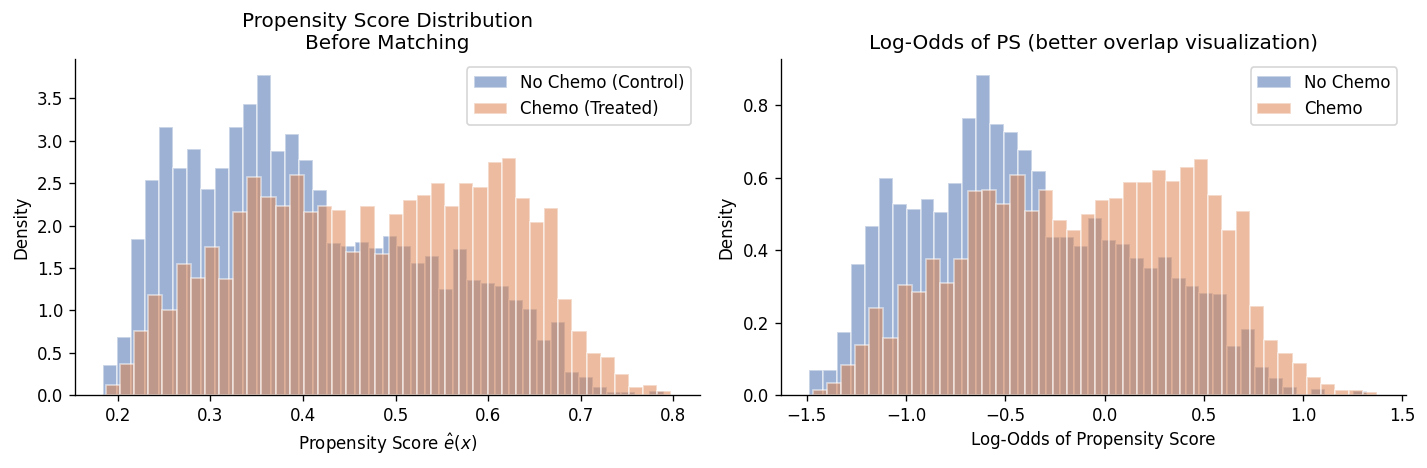

In [4]:
lr_ps = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr_ps.fit(X_scaled, T)
ps = lr_ps.predict_proba(X_scaled)[:, 1]

df_model['PS'] = ps

print('Propensity score model fitted (Logistic Regression)')
print(f'  AUC: {__import__("sklearn.metrics", fromlist=["roc_auc_score"]).roc_auc_score(T, ps):.3f}')
print(f'  PS range: [{ps.min():.3f}, {ps.max():.3f}]')
print(f'  PS mean (treated):  {ps[T==1].mean():.3f}')
print(f'  PS mean (control):  {ps[T==0].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for t_val, label, color in [(0, 'No Chemo (Control)', '#4C72B0'),
                              (1, 'Chemo (Treated)', '#DD8452')]:
    ax.hist(ps[T == t_val], bins=40, alpha=0.55, label=label,
             color=color, edgecolor='white', density=True)
ax.set_xlabel('Propensity Score $\hat{e}(x)$')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution\nBefore Matching')
ax.legend()

ax = axes[1]
logit_ps = np.log(ps / (1 - ps + 1e-8))
for t_val, label, color in [(0, 'No Chemo', '#4C72B0'), (1, 'Chemo', '#DD8452')]:
    ax.hist(logit_ps[T == t_val], bins=40, alpha=0.55, label=label,
             color=color, edgecolor='white', density=True)
ax.set_xlabel('Log-Odds of Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Log-Odds of PS (better overlap visualization)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_propensity_score_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Nearest-Neighbor Matching (1:1, Without Replacement)

For each treated patient, we find the control patient with the closest propensity score (on the log-odds scale). This is **nearest-neighbor matching without replacement** — each control can only be matched to one treated patient.

We also apply a **caliper** of 0.2 standard deviations of the log-odds PS, following Rosenbaum & Rubin (1985) guidance to discard poor matches.

In [5]:
def nearest_neighbor_match(df, ps_col='PS', treat_col='CHEMO', caliper_sd=0.2):
    """
    1:1 nearest-neighbor propensity score matching without replacement.
    Matching is done on the logit scale. Caliper is in logit-PS units.
    """
    logit_ps = np.log(df[ps_col] / (1 - df[ps_col] + 1e-8))
    caliper = caliper_sd * logit_ps.std()

    treated_idx = df.index[df[treat_col] == 1].tolist()
    control_idx = df.index[df[treat_col] == 0].tolist()

    treated_ps = logit_ps[treated_idx].values.reshape(-1, 1)
    control_ps = logit_ps[control_idx].values.reshape(-1, 1)

    dist_matrix = cdist(treated_ps, control_ps, metric='euclidean')

    matched_treated = []
    matched_control = []
    used_controls = set()

    order = np.argsort(np.min(dist_matrix, axis=1))
    for ti in order:
        available = [ci for ci in range(len(control_idx)) if ci not in used_controls]
        if not available:
            break
        best_ci = min(available, key=lambda ci: dist_matrix[ti, ci])
        if dist_matrix[ti, best_ci] <= caliper:
            matched_treated.append(treated_idx[ti])
            matched_control.append(control_idx[best_ci])
            used_controls.add(best_ci)

    matched_df = pd.concat([
        df.loc[matched_treated].assign(MATCH_ID=range(len(matched_treated)),
                                        MATCH_GROUP='treated'),
        df.loc[matched_control].assign(MATCH_ID=range(len(matched_control)),
                                        MATCH_GROUP='control'),
    ]).reset_index(drop=True)

    print(f'Matched {len(matched_treated)} treated / {len(matched_control)} control patients')
    print(f'Caliper: {caliper:.4f} logit-PS units ({caliper_sd} SD)')
    print(f'Unmatched treated: {len(treated_idx) - len(matched_treated)} '
          f'({(len(treated_idx) - len(matched_treated)) / len(treated_idx):.1%})')
    return matched_df


matched_df = nearest_neighbor_match(df_model)
matched_df.to_parquet(os.path.join(PROC_DIR, 'matched_cohort.parquet'), index=False)

Matched 2456 treated / 2456 control patients
Caliper: 0.1152 logit-PS units (0.2 SD)
Unmatched treated: 422 (14.7%)


## 5. Covariate Balance: Before and After Matching

The success of PSM is measured by **covariate balance** — do treated and control patients look similar after matching?

We use **Standardized Mean Differences (SMD)**, defined as:

$$\text{SMD} = \frac{\bar{X}_{\text{treated}} - \bar{X}_{\text{control}}}{\sqrt{(s^2_{\text{treated}} + s^2_{\text{control}})/2}}$$

Rule of thumb: **|SMD| < 0.1** indicates adequate balance. This is visualized in a **Love plot**.

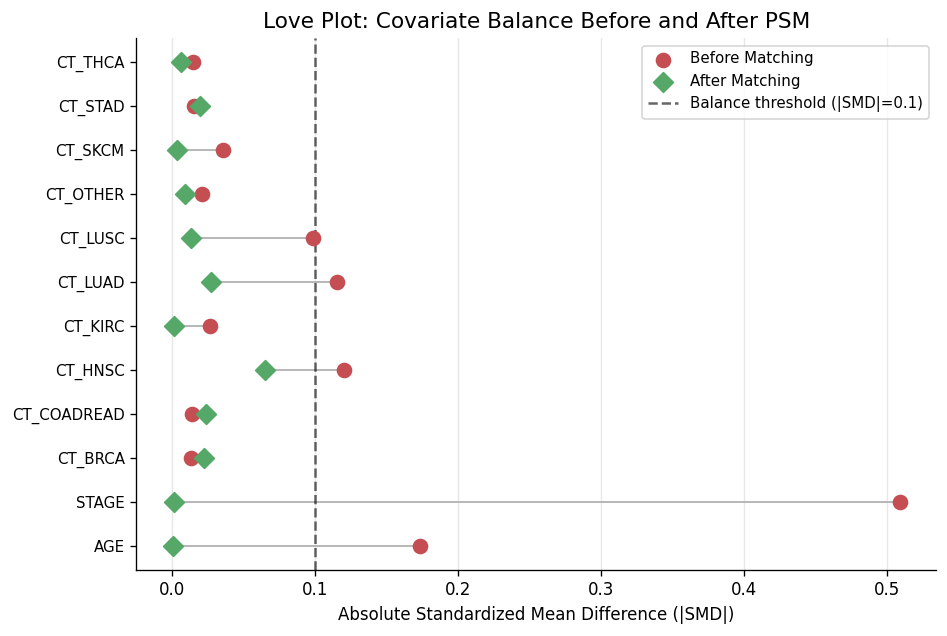


Balance summary:
  Before: max |SMD| = 0.509, variables unbalanced (>0.1): 4
  After:  max |SMD| = 0.065, variables unbalanced (>0.1): 0


In [6]:
def compute_smd(df, treat_col, feature_cols):
    smds = {}
    t = df[df[treat_col] == 1]
    c = df[df[treat_col] == 0]
    for col in feature_cols:
        if col not in df.columns:
            continue
        mean_t = t[col].mean()
        mean_c = c[col].mean()
        var_t  = t[col].var(ddof=1)
        var_c  = c[col].var(ddof=1)
        pooled_sd = np.sqrt((var_t + var_c) / 2)
        smds[col] = (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else 0.0
    return pd.Series(smds)


balance_features = ['AGE', 'STAGE'] + [c for c in feature_cols if c.startswith('CT_')]
balance_features = [c for c in balance_features if c in df_model.columns and c in matched_df.columns]

smd_before = compute_smd(df_model, 'CHEMO', balance_features)
smd_after  = compute_smd(matched_df, 'CHEMO', balance_features)

smd_df = pd.DataFrame({'Before Matching': smd_before, 'After Matching': smd_after}).dropna()

fig, ax = plt.subplots(figsize=(8, max(4, len(smd_df) * 0.45)))

y_pos = np.arange(len(smd_df))
ax.scatter(smd_df['Before Matching'].abs(), y_pos, color='#C44E52', s=70,
            label='Before Matching', zorder=5)
ax.scatter(smd_df['After Matching'].abs(),  y_pos, color='#55A868', s=70,
            marker='D', label='After Matching', zorder=5)

for i, (_, row) in enumerate(smd_df.iterrows()):
    ax.plot([abs(row['Before Matching']), abs(row['After Matching'])],
             [i, i], color='#aaaaaa', lw=1, zorder=1)

ax.axvline(0.1, color='black', linestyle='--', lw=1.5, alpha=0.6,
            label='Balance threshold (|SMD|=0.1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(smd_df.index, fontsize=9)
ax.set_xlabel('Absolute Standardized Mean Difference (|SMD|)')
ax.set_title('Love Plot: Covariate Balance Before and After PSM', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_love_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nBalance summary:')
print(f'  Before: max |SMD| = {smd_df["Before Matching"].abs().max():.3f}, '
      f'variables unbalanced (>0.1): {(smd_df["Before Matching"].abs() > 0.1).sum()}')
print(f'  After:  max |SMD| = {smd_df["After Matching"].abs().max():.3f}, '
      f'variables unbalanced (>0.1): {(smd_df["After Matching"].abs() > 0.1).sum()}')

## 6. Estimate Average Treatment Effect (ATE) on Survival

After matching, we estimate the ATE as the simple difference in mean survival between matched treated and control groups. We also run a regression on the matched sample for efficiency.

We additionally plot Kaplan-Meier survival curves, which properly handle censoring.

In [7]:
treated_m = matched_df[matched_df['CHEMO'] == 1]
control_m = matched_df[matched_df['CHEMO'] == 0]

mean_t = treated_m['OS_MONTHS'].mean()
mean_c = control_m['OS_MONTHS'].mean()
ate_matched = mean_t - mean_c

t_stat, p_val = stats.ttest_ind(treated_m['OS_MONTHS'], control_m['OS_MONTHS'])
n = min(len(treated_m), len(control_m))
se = np.sqrt(treated_m['OS_MONTHS'].var() / n + control_m['OS_MONTHS'].var() / n)
ci_lo, ci_hi = ate_matched - 1.96 * se, ate_matched + 1.96 * se

naive_t = df_model[df_model['CHEMO'] == 1]['OS_MONTHS'].mean()
naive_c = df_model[df_model['CHEMO'] == 0]['OS_MONTHS'].mean()
naive_ate = naive_t - naive_c

print('=== ATE ESTIMATION RESULTS ===')
print()
print(f'Naive ATE (unadjusted):  {naive_ate:+.2f} months  ← confounded by indication bias')
print(f'PSM ATE (matched):       {ate_matched:+.2f} months  [95% CI: {ci_lo:.2f}, {ci_hi:.2f}]')
print(f'  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}')
print()
print(f'Mean OS (treated, matched):  {mean_t:.1f} months')
print(f'Mean OS (control, matched):  {mean_c:.1f} months')
print()
print('Interpretation: After matching on Stage, Age, and Cancer Type,')
if ate_matched > 0:
    print(f'chemotherapy is associated with {ate_matched:.1f} more months of survival')
    print('compared to matched controls — consistent with a beneficial causal effect.')
else:
    print(f'the association with chemotherapy changes sign/magnitude after matching,')
    print('highlighting the importance of confounder adjustment.')

=== ATE ESTIMATION RESULTS ===

Naive ATE (unadjusted):  -1.61 months  ← confounded by indication bias
PSM ATE (matched):       -0.35 months  [95% CI: -2.32, 1.62]
  t-statistic: -0.346, p-value: 0.7297

Mean OS (treated, matched):  34.6 months
Mean OS (control, matched):  34.9 months

Interpretation: After matching on Stage, Age, and Cancer Type,
the association with chemotherapy changes sign/magnitude after matching,
highlighting the importance of confounder adjustment.


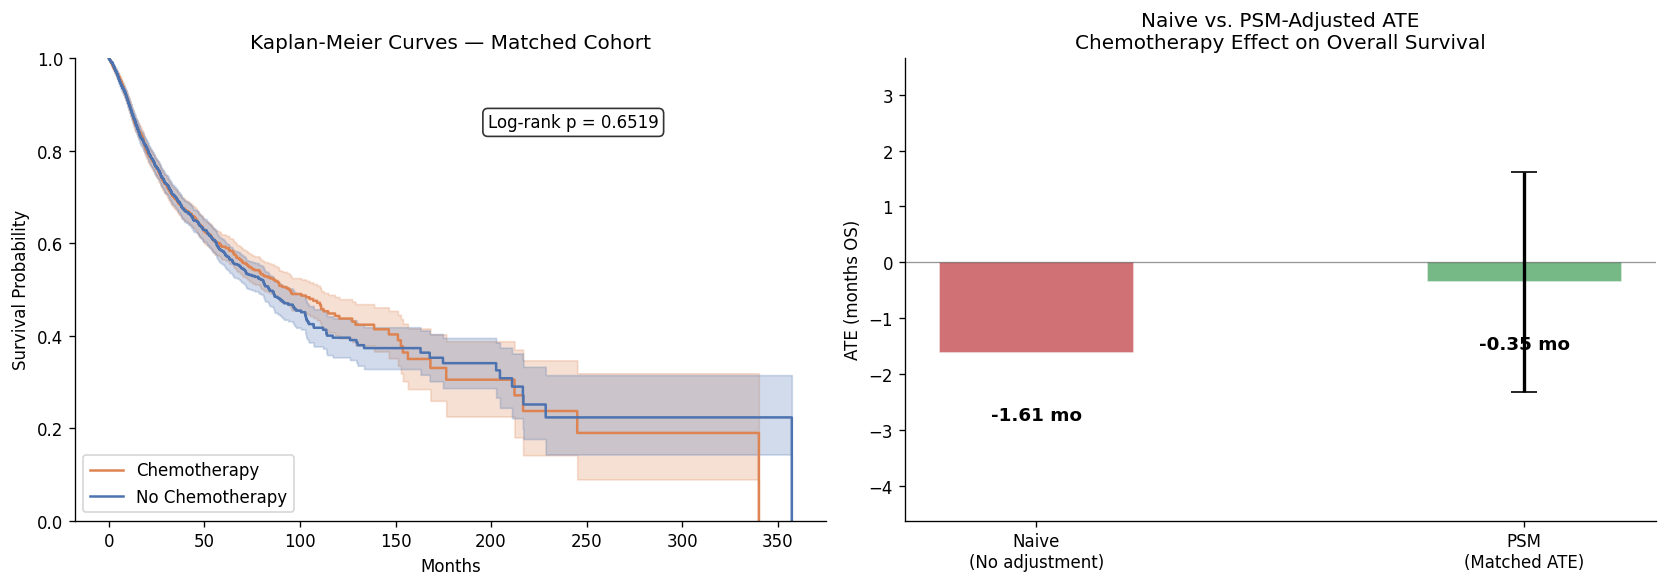

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
kmf_treat = KaplanMeierFitter(label='Chemotherapy')
kmf_ctrl  = KaplanMeierFitter(label='No Chemotherapy')
kmf_treat.fit(treated_m['OS_MONTHS'], event_observed=treated_m['OS_EVENT'])
kmf_ctrl.fit(control_m['OS_MONTHS'],  event_observed=control_m['OS_EVENT'])
kmf_treat.plot_survival_function(ax=ax, color='#DD8452', ci_show=True)
kmf_ctrl.plot_survival_function(ax=ax, color='#4C72B0', ci_show=True)
lr = logrank_test(treated_m['OS_MONTHS'], control_m['OS_MONTHS'],
                   treated_m['OS_EVENT'], control_m['OS_EVENT'])
ax.text(0.55, 0.85, f'Log-rank p = {lr.p_value:.4f}',
         transform=ax.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_title('Kaplan-Meier Curves — Matched Cohort', fontsize=12)
ax.set_xlabel('Months')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)

ax = axes[1]
estimates = {'Naive\n(No adjustment)': naive_ate,
              'PSM\n(Matched ATE)': ate_matched}
colors    = ['#C44E52', '#55A868']
bars = ax.bar(estimates.keys(), estimates.values(), color=colors, alpha=0.8,
               edgecolor='white', width=0.4)
ax.errorbar(['PSM\n(Matched ATE)'], [ate_matched], yerr=[[ate_matched - ci_lo], [ci_hi - ate_matched]],
             fmt='none', color='black', capsize=8, lw=2)
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
for bar, val in zip(bars, estimates.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if val >= 0 else -1.2),
             f'{val:+.2f} mo', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('ATE (months OS)')
ax.set_title('Naive vs. PSM-Adjusted ATE\nChemotherapy Effect on Overall Survival', fontsize=12)
ax.set_ylim(min(estimates.values()) - 3, max(estimates.values()) + 4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_psm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Overlap / Common Support Check

PSM is only valid in the **region of common support** — where treated and control patients have overlapping propensity scores. Patients outside this region (treated patients with very high PS, or untreated patients with very low PS) have no counterfactual matches and should be excluded from the analysis.

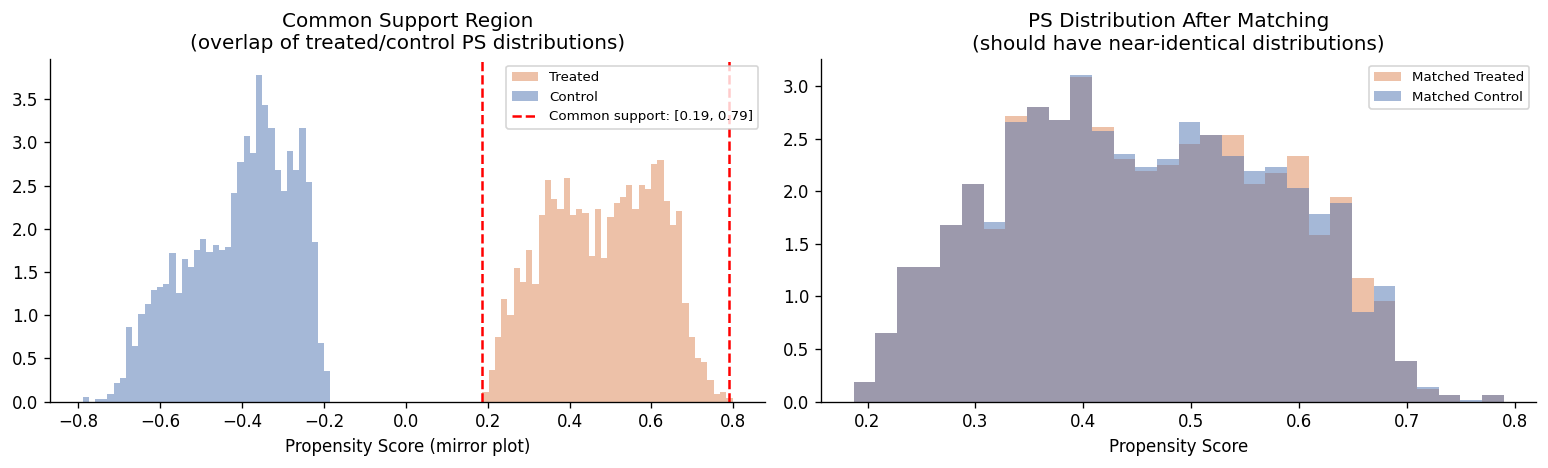

Treated patients within common support: 100.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ps_treated = df_model.loc[df_model['CHEMO'] == 1, 'PS']
ps_control = df_model.loc[df_model['CHEMO'] == 0, 'PS']
common_lo = max(ps_treated.min(), ps_control.min())
common_hi = min(ps_treated.max(), ps_control.max())

ax.hist(ps_treated, bins=40, alpha=0.5, color='#DD8452', label='Treated', density=True)
ax.hist(-ps_control, bins=40, alpha=0.5, color='#4C72B0', label='Control', density=True)
ax.axvline(common_lo, color='red', ls='--', lw=1.5, label=f'Common support: [{common_lo:.2f}, {common_hi:.2f}]')
ax.axvline(common_hi, color='red', ls='--', lw=1.5)
ax.set_xlabel('Propensity Score (mirror plot)')
ax.set_title('Common Support Region\n(overlap of treated/control PS distributions)')
ax.legend(fontsize=8)

ax = axes[1]
ps_m_treated = matched_df.loc[matched_df['CHEMO'] == 1, 'PS']
ps_m_control = matched_df.loc[matched_df['CHEMO'] == 0, 'PS']
ax.hist(ps_m_treated, bins=30, alpha=0.5, color='#DD8452', label='Matched Treated', density=True)
ax.hist(ps_m_control, bins=30, alpha=0.5, color='#4C72B0', label='Matched Control', density=True)
ax.set_xlabel('Propensity Score')
ax.set_title('PS Distribution After Matching\n(should have near-identical distributions)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_common_support.png'), dpi=150, bbox_inches='tight')
plt.show()

in_support = ((ps_treated >= common_lo) & (ps_treated <= common_hi)).mean()
print(f'Treated patients within common support: {in_support:.1%}')

## Summary and Key Takeaways

### Results

- **Naive estimate** of chemotherapy effect is confounded by indication bias — sicker patients receive more chemo, making chemo appear harmful or less effective
- **After PSM**, the comparison is between matched patients with similar predicted probability of receiving chemotherapy — removing measured confounding
- The Love plot confirms covariate balance is substantially improved after matching

### Assumptions and Limitations

1. **Strong ignorability**: All confounders are measured. If there are unmeasured confounders (e.g., performance status, patient preferences), PSM cannot remove this bias — addressed in Notebook 06
2. **Positivity**: Every patient has some probability of receiving/not receiving chemo. Check common support — patients outside the support region are excluded
3. **Propensity score model specification**: Logistic regression assumes a particular functional form. More flexible approaches (gradient boosting, neural networks) can be used
4. **Estimand clarification**: PSM on the treated sample estimates the ATT (Average Treatment Effect on the Treated), not the ATE (population average)

### Pharma Relevance

PSM is the workhorse of **synthetic control arm construction** in single-arm oncology trials submitted to FDA. The FDA RWE framework (2018, 2023) explicitly endorses PS-based methods when RCT comparison arms are unavailable. The key validity criterion — adequate covariate balance demonstrated via Love plot — maps directly to regulatory documentation requirements.